Competition description

Twitter has become an important communication channel in times of emergency.
The ubiquitousness of smartphones enables people to announce an emergency they’re observing in real-time. Because of this, more agencies are interested in programatically monitoring Twitter (i.e. disaster relief organizations and news agencies).

But, it’s not always clear whether a person’s words are actually announcing a disaster.

Acknowledgments

This dataset was created by the company figure-eight and originally shared on their ‘Data For Everyone’ website here.

Import libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore", category=DeprecationWarning)
%matplotlib inline

Loads train, test, and sample files

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/nlp-getting-started/sample_submission.csv
/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/nlp-getting-started/test.csv


Read

In [3]:
train  = pd.read_csv('/kaggle/input/nlp-getting-started/train.csv')
test = pd.read_csv('/kaggle/input/nlp-getting-started/test.csv')
submission = pd.read_csv('/kaggle/input/nlp-getting-started/sample_submission.csv')

In [4]:
train

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


In [5]:
test

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan
...,...,...,...,...
3258,10861,NaN,NaN,EARTHQUAKE SAFETY LOS ANGELES ÛÒ SAFETY FASTE...
3259,10865,NaN,NaN,Storm in RI worse than last hurricane. My city...
3260,10868,NaN,NaN,Green Line derailment in Chicago http://t.co/U...
3261,10874,NaN,NaN,MEG issues Hazardous Weather Outlook (HWO) htt...


In [6]:
submission

,id,target
0,0,0
1,2,0
2,3,0
3,9,0
4,11,0
...,...,...
3258,10861,0
3259,10865,0
3260,10868,0
3261,10874,0


Combine train and test

In [7]:
target = train.target
train.drop('target', axis=1, inplace=True)
train

,id,keyword,location,text
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or..."
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...
...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...


In [8]:
combi = train.append(test)
combi

,id,keyword,location,text
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or..."
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...
...,...,...,...,...
3258,10861,NaN,NaN,EARTHQUAKE SAFETY LOS ANGELES ÛÒ SAFETY FASTE...
3259,10865,NaN,NaN,Storm in RI worse than last hurricane. My city...
3260,10868,NaN,NaN,Green Line derailment in Chicago http://t.co/U...
3261,10874,NaN,NaN,MEG issues Hazardous Weather Outlook (HWO) htt...


Compare tweets in train and test file

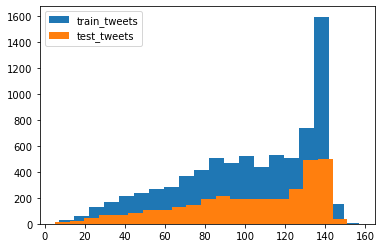

In [9]:
#compare tweets in train and test file
length_train=train['text'].str.len()
length_test=test['text'].str.len()
plt.hist(length_train, bins=20, label="train_tweets")
plt.hist(length_test, bins=20, label="test_tweets")
plt.legend()
plt.show()

Identify percentage of disaster tweets

In [10]:
target.value_counts()

0    4342
1    3271
Name: target, dtype: int64

In [11]:
percentage_disaster=(target.value_counts() / len(train)) * 100
percentage_disaster

0    57.034021
1    42.965979
Name: target, dtype: float64

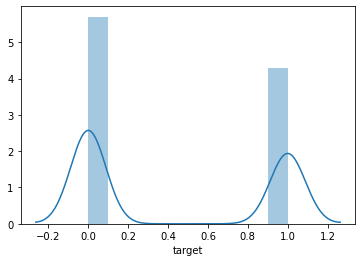

In [12]:
sns.distplot(target)

{'whiskers': [<matplotlib.lines.Line2D at 0x7f72fc4733d0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f72fc473e50>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f72fc46bdd0>],
 'medians': [<matplotlib.lines.Line2D at 0x7f72fc47b950>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f72fc473c10>],
 'means': []}

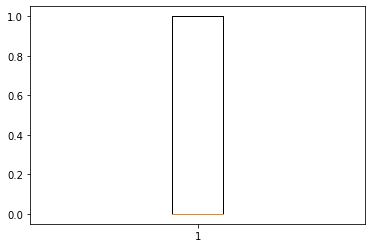

In [13]:
plt.boxplot(target)

Preprocessing raw text and getting it ready for machine learning

In [14]:
tweets = combi['text']

count_words = tweets.str.findall(r'(\w+)').str.len()
print(count_words.sum())

186117


In [15]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

stopwords = set(stopwords.words("english"))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

""" Cleaning Tweets """
tweets = tweets.str.lower()

#stem the text
#tweets = tweets.apply(lambda x: " ".join([stemmer.stem(i)
#for i in re.sub("[^a-zA-Z]", " ", x).split() if i not in stopwords]).lower())

#lemmatize the text
tweets = tweets.apply(lambda x: " ".join([lemmatizer.lemmatize(i)
for i in re.sub("[^a-zA-Z]", " ", x).split() if i not in stopwords]).lower())

# removing special characters and numbers
tweets = tweets.apply(lambda x : re.sub("[^a-z]\s","",x) )

# remove hash tags
tweets = tweets.str.replace("#", "")

#remove words less than 3 character and greater than 7
tweets = tweets.apply(lambda x: ' '.join([w for w in x.split() if len(w)>2 and len(w)<8]))

# removing stopwords
tweets = tweets.apply(lambda x : " ".join(word for word in x.split() if word not in stopwords ))

count_words = tweets.str.findall(r'(\w+)').str.len()
print(count_words.sum())

84699


Remove frequently used words

In [16]:
most_freq_words = pd.Series(' '.join(tweets).lower().split()).value_counts()[:1]
tweets = tweets.apply(lambda x : " ".join(word for word in x.split() if word not in most_freq_words ))
print(most_freq_words)

count_words = tweets.str.findall(r'(\w+)').str.len()
print(count_words.sum())

http    6780
dtype: int64
77919


Remove rare words

In [17]:
from collections import Counter
from itertools import chain

# split words into lists
v = tweets.str.split().tolist() 
# compute global word frequency
c = Counter(chain.from_iterable(v))
# filter, join, and re-assign
tweets = [' '.join([j for j in i if c[j] > 1]) for i in v]

total_word = 0
for x,word in enumerate(tweets):
    num_word = len(word.split())
    #print(num_word)
    total_word = total_word + num_word
print(total_word)

67038


Create tokens in spacy

In [18]:
!pip install spacy

You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


In [19]:
import spacy
import spacy.cli
spacy.cli.download("en_vectors_web_lg")
nlp = spacy.load('en_vectors_web_lg')

✔ Download and installation successful
You can now load the model via spacy.load('en_vectors_web_lg')


In [20]:
import spacy
import en_vectors_web_lg

nlp = en_vectors_web_lg.load()
document = nlp(tweets[0])
print("Document : ",document)
print("Tokens : ")
for token in document:
       print(token.text)

Document :  deed reason may allah forgive
Tokens : 
deed
reason
may
allah
forgive


Token to vector

In [21]:
document = nlp(tweets[0])
print(document)
for token in document:
    print(token.text, token.vector.shape)

deed reason may allah forgive
deed (300,)
reason (300,)
may (300,)
allah (300,)
forgive (300,)


Sentence to vector using pipe

In [22]:
document = nlp.pipe(tweets)
tweets_vector = np.array([tweet.vector for tweet in document])
print(tweets_vector.shape)

(10876, 300)


Define X, y and X_test

In [23]:
#define x, y and t_test
y = target
X=tweets_vector[: len(train)]
X_test=tweets_vector[len(train) :]

Split train set for training and testing

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.10, random_state=42, shuffle=True)
X_train.shape, X_val.shape, y_train.shape,y_val.shape, X_test.shape

((6851, 300), (762, 300), (6851,), (762,), (3263, 300))

Define and train the model

In [25]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(random_state=42).fit(X_train, y_train)
print(model.score(X_train, y_train))

0.9797109910961903


Predict on validation set

In [26]:
y_pred = model.predict(X_val)
print(model.score(X_val, y_val))

0.7611548556430446


In [27]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_val, y_pred))

[[356  79]
 [103 224]]


In [28]:
df = pd.DataFrame({'Actual': y_val, 'Predicted':y_pred})
df

,Actual,Predicted
1224,0,1
7007,0,0
6490,0,0
5337,0,0
38,1,1
...,...,...
5114,1,0
6306,0,0
5605,1,1
896,0,1


Predict on test set

In [29]:
test_pred = model.predict(X_test)
test_pred

array([1, 1, 1, ..., 1, 1, 0])

Submission

In [30]:
submission['target'] = test_pred
submission.to_csv('submission.csv',index=False) # writing data to a CSV file
submission = pd.read_csv("submission.csv")
submission

,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1
...,...,...
3258,10861,1
3259,10865,1
3260,10868,1
3261,10874,1
